# Assignment 2: Image-to-Video Semantic Retrieval via Object Detection
**CS-GY-6613-INET2, Spring 2026**


## 0: Install


In [ ]:
!pip install -q ultralytics datasets huggingface_hub pyarrow yt-dlp
!apt-get install -y -q ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.5 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
# verifying GPU is available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: Tesla T4


## 1: HuggingFace


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# HuggingFace username
HF_USERNAME = "rolandchi"
HF_REPO_ID = f"{HF_USERNAME}/car-parts-detections-v2"

## 2: Training YOLO on car parts dataset

Fine-tuning YOLOv8-nano on the car-parts-seg dataset.

In [ ]:
!rm -rf carparts-seg carparts-seg.zip

In [ ]:
import subprocess

# download the car-parts-seg dataset
subprocess.run([
    "wget", "-q",
    "https://github.com/ultralytics/assets/releases/download/v0.0.0/carparts-seg.zip"
], check=True)

# unzip it
subprocess.run(["unzip", "-q", "carparts-seg.zip", "-d", "carparts-seg"], check=True)

print("Dataset downloaded and extracted")

Dataset downloaded and extracted


In [ ]:
import glob
yamls = glob.glob("carparts-seg/**/*.yaml", recursive=True)
print(yamls)

['carparts-seg/carparts-seg.yaml']


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00


In [ ]:
import glob
from ultralytics import YOLO

# find the actual yaml path
yamls = glob.glob("carparts-seg/**/*.yaml", recursive=True)
if not yamls:
    yamls = glob.glob("**/*.yaml", recursive=True)
print(f"Found: {yamls}")

yaml_path = yamls[0]
print(f"Using: {yaml_path}")

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    name="car_parts",
    patience=5
)

print("Training done!")

Found: ['carparts-seg/carparts-seg.yaml']
Using: carparts-seg/carparts-seg.yaml
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=carparts-seg/carparts-seg.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=car_parts2, nbs=64, nms=False

In [ ]:
# load the best weights from training
import glob

# find the best.pt file (path can vary slightly)
weight_paths = glob.glob("runs/segment/car_parts*/weights/best.pt")
if weight_paths:
    best_weights = weight_paths[0]
    print(f"Using weights: {best_weights}")
else:
    best_weights = "runs/segment/car_parts/weights/best.pt"
    print(f"Assuming default path: {best_weights}")

model = YOLO(best_weights)
print(f"Model classes: {model.names}")

Using weights: runs/segment/car_parts2/weights/best.pt
Model classes: {0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_left_door', 4: 'back_left_light', 5: 'back_light', 6: 'back_right_door', 7: 'back_right_light', 8: 'front_bumper', 9: 'front_door', 10: 'front_glass', 11: 'front_left_door', 12: 'front_left_light', 13: 'front_light', 14: 'front_right_door', 15: 'front_right_light', 16: 'hood', 17: 'left_mirror', 18: 'object', 19: 'right_mirror', 20: 'tailgate', 21: 'trunk', 22: 'wheel'}


## 3: Download video, extract frames

In [ ]:
# Check if cookies file is actually where we think it is
!ls -la /content/cookies.txt

# Install a JS runtime that yt-dlp needs
!pip install pyinstaller 2>/dev/null
!apt-get install -y nodejs 2>/dev/null

ls: cannot access '/content/cookies.txt': No such file or directory
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.4/741.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.8/452.8 kB 39.6 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  javascript-common libc-ares2 libjs-highlight.js libnode72 nodejs-doc
Suggested packages:
  apache2 | lighttpd | httpd npm
The following NEW packages will be installed:
  javascript-common libc-ares2 libjs-highlight.js libnode72 nodejs nodejs-doc
0 upgraded, 6 newly installed, 0 to remove and 37 not upgraded.
Need to get 13.7 MB of archives.
After this operation, 54.0 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 javascript-common all 11+nmu1 [5,936 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjs-highlight.js all 9.18.5+dfsg1-1 [367 kB]
Get

In [ ]:
import os

VIDEO_URL = "https://www.youtube.com/watch?v=YcvECxtXoxQ"
VIDEO_FILE = "input_video.mp4"

if not os.path.exists(VIDEO_FILE):
    !yt-dlp --cookies /content/www.youtube.com_cookies.txt --remote-components ejs:github -f "bestvideo[height<=480][ext=mp4]+bestaudio[ext=m4a]/best[height<=480]" -o input_video.mp4 "https://www.youtube.com/watch?v=YcvECxtXoxQ"
else:
    print(f"{VIDEO_FILE} already exists")

!ffprobe -v error -show_entries format=duration -of default=noprint_wrappers=1:nokey=1 {VIDEO_FILE}

input_video.mp4 already exists
2793.849000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf frames/*

In [ ]:
FRAMES_DIR = "frames"
os.makedirs(FRAMES_DIR, exist_ok=True)

# extract at 1/5 frame per second
!ffmpeg -i {VIDEO_FILE} -vf "fps=1/5" {FRAMES_DIR}/frame_%05d.jpg -y -stats

frame_files = sorted([f for f in os.listdir(FRAMES_DIR) if f.endswith(".jpg")])
print(f"Extracted {len(frame_files)} frames")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## 4: Run object detection on every frame

Core indexing step. Run YOLO on each frame and collect all detections.

In [ ]:
import pandas as pd
from pathlib import Path

CONFIDENCE_THRESHOLD = 0.25

frame_paths = sorted(Path(FRAMES_DIR).glob("*.jpg"))
all_detections = []

for i, frame_path in enumerate(frame_paths):
    frame_idx = i + 1
    timestamp_sec = frame_idx  # at 1fps, frame N = second N

    results = model(str(frame_path), verbose=False)

    for result in results:
        if result.boxes is None:
            continue
        boxes = result.boxes
        for j in range(len(boxes)):
            conf = float(boxes.conf[j])
            if conf < CONFIDENCE_THRESHOLD:
                continue
            cls_id = int(boxes.cls[j])
            cls_name = model.names.get(cls_id, f"class_{cls_id}")
            x1, y1, x2, y2 = boxes.xyxy[j].tolist()

            all_detections.append({
                "video_id": "YcvECxtXoxQ",
                "frame_index": frame_idx,
                "timestamp_sec": timestamp_sec,
                "class_label": cls_name,
                "x_min": round(x1, 1),
                "y_min": round(y1, 1),
                "x_max": round(x2, 1),
                "y_max": round(y2, 1),
                "confidence_score": round(conf, 4),
                "detector_name": "yolov8n-seg-carparts"
            })

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(frame_paths)} frames, {len(all_detections)} detections so far")

print(f"\nDone! Total detections: {len(all_detections)}")

Processed 50/559 frames, 104 detections so far
Processed 100/559 frames, 185 detections so far
Processed 150/559 frames, 219 detections so far
Processed 200/559 frames, 266 detections so far
Processed 250/559 frames, 529 detections so far
Processed 300/559 frames, 754 detections so far
Processed 350/559 frames, 1030 detections so far
Processed 400/559 frames, 1075 detections so far
Processed 450/559 frames, 1156 detections so far
Processed 500/559 frames, 1265 detections so far
Processed 550/559 frames, 1368 detections so far

Done! Total detections: 1449


In [ ]:
# save to parquet
df = pd.DataFrame(all_detections)
PARQUET_FILE = "video_detections.parquet"
df.to_parquet(PARQUET_FILE, index=False)

print(f"Saved {len(df)} detections to {PARQUET_FILE}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df["class_label"].value_counts())
print(f"\nFrames with detections: {df['frame_index'].nunique()} / {len(frame_paths)}")

Saved 1449 detections to video_detections.parquet

Columns: ['video_id', 'frame_index', 'timestamp_sec', 'class_label', 'x_min', 'y_min', 'x_max', 'y_max', 'confidence_score', 'detector_name']

Class distribution:
class_label
wheel                243
back_glass           193
trunk                135
back_bumper          135
right_mirror         118
front_bumper          93
front_glass           84
hood                  73
back_left_light       54
tailgate              50
front_right_door      45
front_right_light     43
front_left_light      40
front_left_door       35
left_mirror           30
back_left_door        29
back_right_door       22
back_light            21
front_light            3
back_right_light       3
Name: count, dtype: int64

Frames with detections: 461 / 559


In [ ]:
# look at a few rows
df.head(10)

,video_id,frame_index,timestamp_sec,class_label,x_min,y_min,x_max,y_max,confidence_score,detector_name
0,YcvECxtXoxQ,1,1,front_glass,371.0,121.1,614.7,207.3,0.9081,yolov8n-seg-carparts
1,YcvECxtXoxQ,1,1,wheel,59.5,278.1,570.6,464.1,0.8644,yolov8n-seg-carparts
2,YcvECxtXoxQ,1,1,front_bumper,554.4,274.0,829.9,417.3,0.7966,yolov8n-seg-carparts
3,YcvECxtXoxQ,1,1,hood,469.2,202.5,817.1,252.9,0.6900,yolov8n-seg-carparts
4,YcvECxtXoxQ,1,1,front_left_door,250.8,119.1,420.1,369.0,0.5354,yolov8n-seg-carparts
5,YcvECxtXoxQ,1,1,back_left_light,35.0,186.4,56.1,215.2,0.5284,yolov8n-seg-carparts
6,YcvECxtXoxQ,1,1,front_right_door,249.7,118.1,420.3,369.8,0.5124,yolov8n-seg-carparts
7,YcvECxtXoxQ,1,1,back_right_door,116.5,115.2,270.9,366.7,0.3886,yolov8n-seg-carparts
8,YcvECxtXoxQ,1,1,back_left_door,116.4,114.7,271.1,367.9,0.3077,yolov8n-seg-carparts
9,YcvECxtXoxQ,2,2,trunk,90.8,146.9,406.0,325.8,0.9210,yolov8n-seg-carparts


## 5: Query retrieval

Loading query images from the HuggingFace dataset and search the index.

In [ ]:
from datasets import load_dataset

ds = load_dataset("aegean-ai/rav4-exterior-images", split="train")
print(f"Query dataset: {len(ds)} images")
print(f"Columns: {ds.column_names}")

README.md:   0%|          | 0.00/505 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/69.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/65 [00:00<?, ? examples/s]

Query dataset: 65 images
Columns: ['image', 'timestamp', 'timestamp_sec', 'exterior_score', 'width', 'height', 'video_title']


In [ ]:
import numpy as np

GAP_TOLERANCE = 3  # seconds

def detect_query_image(model, image):
    """Run detector on a query image, return list of detected classes."""
    results = model(image, verbose=False)
    detected = []
    for result in results:
        if result.boxes is None:
            continue
        for j in range(len(result.boxes)):
            conf = float(result.boxes.conf[j])
            if conf < CONFIDENCE_THRESHOLD:
                continue
            cls_id = int(result.boxes.cls[j])
            cls_name = model.names.get(cls_id, f"class_{cls_id}")
            detected.append({"class_label": cls_name, "confidence": round(conf, 4)})
    return detected


def find_contiguous_segments(df_class, gap_tolerance=GAP_TOLERANCE):
    """Group timestamps into contiguous segments with gap tolerance."""
    if df_class.empty:
        return []
    timestamps = sorted(df_class["timestamp_sec"].unique())
    segments = []
    seg_start = timestamps[0]
    seg_end = timestamps[0]
    seg_count = 1

    for t in timestamps[1:]:
        if t - seg_end <= gap_tolerance:
            seg_end = t
            seg_count += 1
        else:
            segments.append({
                "start_timestamp": int(seg_start),
                "end_timestamp": int(seg_end),
                "num_supporting_detections": seg_count
            })
            seg_start = t
            seg_end = t
            seg_count = 1

    segments.append({
        "start_timestamp": int(seg_start),
        "end_timestamp": int(seg_end),
        "num_supporting_detections": seg_count
    })
    return segments


def retrieve_clips(query_detections, detection_index):
    """Match query detections against video index."""
    results = []
    for det in query_detections:
        label = det["class_label"]
        df_match = detection_index[detection_index["class_label"] == label]
        segments = find_contiguous_segments(df_match)
        for seg in segments:
            seg["class_label"] = label
            seg["query_confidence"] = det["confidence"]
            seg["verify_url"] = (
                f"https://www.youtube.com/embed/YcvECxtXoxQ"
                f"?start={seg['start_timestamp']}&end={seg['end_timestamp']}"
            )
        results.extend(segments)
    return results

print("Retrieval functions ready")

Retrieval functions ready


In [ ]:
# run retrieval on a sample of query images
NUM_QUERIES = 10
sample_indices = np.linspace(0, len(ds) - 1, NUM_QUERIES, dtype=int)

all_query_results = []

for idx in sample_indices:
    item = ds[int(idx)]
    image = item["image"]
    timestamp = item.get("timestamp", "unknown")

    detections = detect_query_image(model, image)
    if not detections:
        print(f"Query {idx} (t={timestamp}): no detections")
        continue

    clips = retrieve_clips(detections, df)
    for clip in clips:
        clip["query_index"] = int(idx)
        clip["query_timestamp"] = timestamp
    all_query_results.extend(clips)

    class_labels = [d["class_label"] for d in detections]
    print(f"Query {idx} (t={timestamp}): detected {class_labels}, retrieved {len(clips)} clips")

print(f"\nTotal retrieval results: {len(all_query_results)}")

Query 0 (t=00:00): detected ['front_glass', 'wheel', 'front_bumper', 'front_right_door', 'back_left_door'], retrieved 81 clips
Query 7 (t=01:55): detected ['front_right_door'], retrieved 21 clips
Query 14 (t=03:25): detected ['front_bumper', 'front_glass', 'hood', 'wheel', 'wheel', 'front_left_light'], retrieved 89 clips
Query 21 (t=04:00): detected ['front_bumper', 'back_glass', 'left_mirror', 'right_mirror', 'right_mirror', 'front_glass', 'right_mirror'], retrieved 140 clips
Query 28 (t=04:35): detected ['front_glass', 'hood', 'wheel', 'wheel', 'left_mirror', 'front_left_door', 'right_mirror', 'front_right_door', 'wheel', 'right_mirror'], retrieved 170 clips
Query 35 (t=05:10): detected ['right_mirror', 'wheel', 'wheel', 'front_right_door', 'wheel'], retrieved 97 clips
Query 42 (t=05:50): detected ['right_mirror', 'front_left_door', 'back_right_door', 'left_mirror'], retrieved 62 clips
Query 49 (t=06:25): detected ['trunk', 'back_glass', 'tailgate', 'back_bumper', 'back_bumper', 'bac

In [ ]:
# view retrieval results
if all_query_results:
    results_df = pd.DataFrame(all_query_results)
    results_df.to_csv("retrieval_results.csv", index=False)
    display(results_df)
else:
    print("No retrieval results. Check if detections are working.")

,start_timestamp,end_timestamp,num_supporting_detections,class_label,query_confidence,verify_url,query_index,query_timestamp
0,1,1,1,front_glass,0.9478,https://www.youtube.com/embed/YcvECxtXoxQ?star...,0,00:00
1,31,31,1,front_glass,0.9478,https://www.youtube.com/embed/YcvECxtXoxQ?star...,0,00:00
2,225,262,31,front_glass,0.9478,https://www.youtube.com/embed/YcvECxtXoxQ?star...,0,00:00
3,300,336,34,front_glass,0.9478,https://www.youtube.com/embed/YcvECxtXoxQ?star...,0,00:00
4,469,469,1,front_glass,0.9478,https://www.youtube.com/embed/YcvECxtXoxQ?star...,0,00:00
...,...,...,...,...,...,...,...,...
1087,469,471,2,back_left_door,0.2932,https://www.youtube.com/embed/YcvECxtXoxQ?star...,64,18:10
1088,477,479,2,back_left_door,0.2932,https://www.youtube.com/embed/YcvECxtXoxQ?star...,64,18:10
1089,500,500,1,back_left_door,0.2932,https://www.youtube.com/embed/YcvECxtXoxQ?star...,64,18:10
1090,549,549,1,back_left_door,0.2932,https://www.youtube.com/embed/YcvECxtXoxQ?star...,64,18:10


## 6: Visualize results

Checking a [link text](https://)few detections visually to make sure they look right.

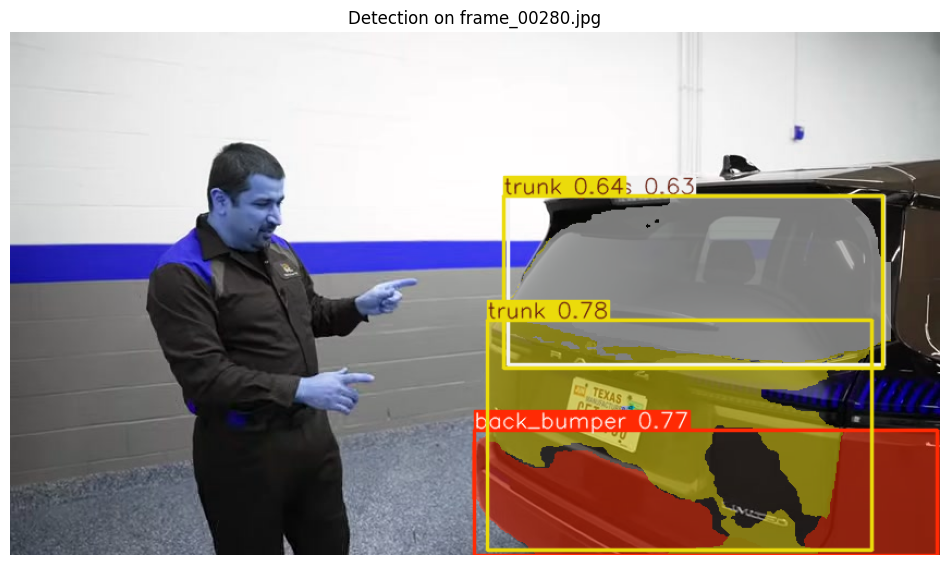

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# show detection on a sample frame
sample_frame = str(frame_paths[len(frame_paths) // 2])  # middle frame
results = model(sample_frame)

# ultralytics has a built-in plot method
annotated = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.title(f"Detection on {os.path.basename(sample_frame)}")
plt.axis("off")
plt.show()

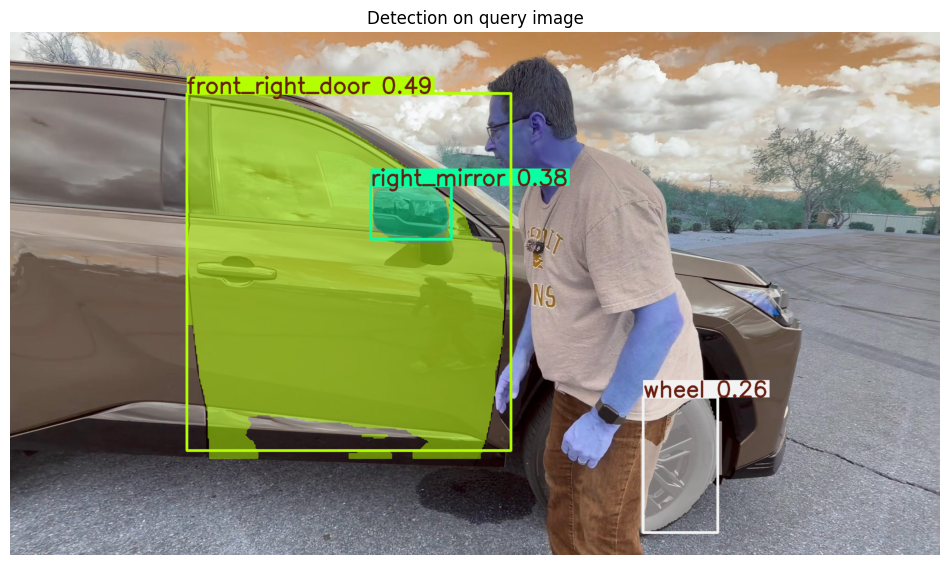

In [ ]:
# show detection on a query image
query_img = ds[len(ds) // 2]["image"]
results = model(query_img)
annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.title("Detection on query image")
plt.axis("off")
plt.show()

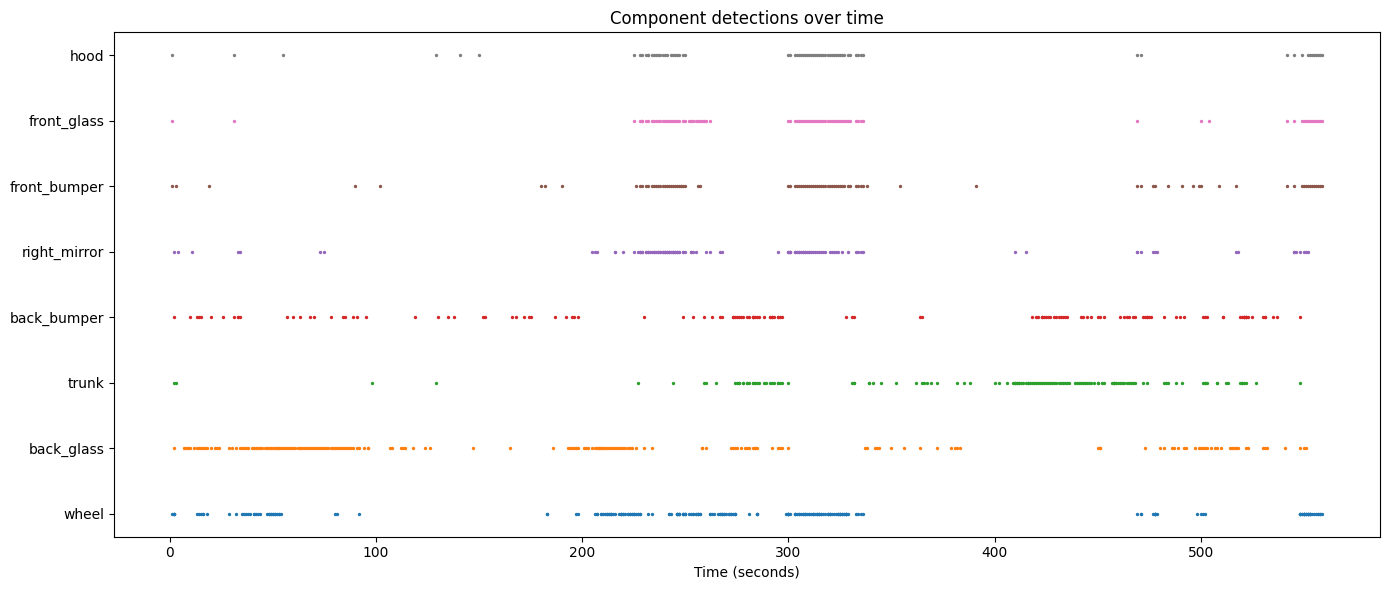

In [ ]:
# show class distribution across the video as a timeline
top_classes = df["class_label"].value_counts().head(8).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for i, cls in enumerate(top_classes):
    cls_df = df[df["class_label"] == cls]
    ax.scatter(cls_df["timestamp_sec"], [i] * len(cls_df), s=2, label=cls)

ax.set_yticks(range(len(top_classes)))
ax.set_yticklabels(top_classes)
ax.set_xlabel("Time (seconds)")
ax.set_title("Component detections over time")
plt.tight_layout()
plt.show()

## 7: Upload to HuggingFace

In [ ]:
# create the README for the HF repo
readme_text = f"""# Car Parts Video Detections

Object detection results for a car exterior review video, used for image-to-video semantic retrieval.

## Source

Video: [YouTube YcvECxtXoxQ](https://www.youtube.com/watch?v=YcvECxtXoxQ)

Detector: YOLOv8n-seg fine-tuned on the [Ultralytics car-parts-seg dataset](https://docs.ultralytics.com/datasets/segment/carparts-seg/)

Sampling rate: 1 frame per second

## Schema

| Column | Type | Description |
|--------|------|-------------|
| video_id | string | YouTube video ID |
| frame_index | int | 1-indexed frame number |
| timestamp_sec | int | Seconds into the video |
| class_label | string | Detected car part (e.g. "hood", "wheel") |
| x_min | float | Bounding box left edge (pixels) |
| y_min | float | Bounding box top edge (pixels) |
| x_max | float | Bounding box right edge (pixels) |
| y_max | float | Bounding box bottom edge (pixels) |
| confidence_score | float | Detection confidence (0 to 1) |
| detector_name | string | Model identifier |

## Stats

- Total detections: {len(df)}
- Frames processed: {len(frame_paths)}
- Frames with detections: {df['frame_index'].nunique()}
- Classes detected: {df['class_label'].nunique()}

## Usage

```python
import pandas as pd
df = pd.read_parquet("video_detections.parquet")
hood_frames = df[df["class_label"] == "hood"]
```

## Assignment

CS-GY-6613-INET2, Spring 2026, Assignment 2
"""

with open("README.md", "w") as f:
    f.write(readme_text)

print("README.md created")

README.md created


In [ ]:
from huggingface_hub import HfApi

api = HfApi()

# create the repo
api.create_repo(HF_REPO_ID, repo_type="dataset", exist_ok=True)

# upload parquet
api.upload_file(
    path_or_fileobj=PARQUET_FILE,
    path_in_repo="video_detections.parquet",
    repo_id=HF_REPO_ID,
    repo_type="dataset"
)

# upload readme
api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=HF_REPO_ID,
    repo_type="dataset"
)

print(f"Uploaded to: https://huggingface.co/datasets/{HF_REPO_ID}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  video_detections.parquet    : 100%|##########| 52.9kB / 52.9kB            

/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:9786: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Uploaded to: https://huggingface.co/datasets/rolandchi/car-parts-detections-v2


## 8: Print numbers for the report

Copy into report.

In [ ]:
print("=" * 50)
print("NUMBERS FOR REPORT")
print("=" * 50)
print(f"Total frames processed: {len(frame_paths)}")
print(f"Total detections: {len(df)}")
print(f"Frames with at least one detection: {df['frame_index'].nunique()}")
print(f"Unique classes detected: {df['class_label'].nunique()}")
print(f"Average detections per frame: {len(df) / len(frame_paths):.1f}")
print(f"Confidence threshold used: {CONFIDENCE_THRESHOLD}")
print(f"Gap tolerance for segments: {GAP_TOLERANCE} seconds")
print(f"\nClass distribution:")
print(df["class_label"].value_counts().to_string())
print(f"\nQuery results: {len(all_query_results)} total clips retrieved across {NUM_QUERIES} queries")
if all_query_results:
    print(f"\nSample verification URLs:")
    for r in all_query_results[:5]:
        print(f"  {r['class_label']}: {r['verify_url']}")

NUMBERS FOR REPORT
Total frames processed: 559
Total detections: 1449
Frames with at least one detection: 461
Unique classes detected: 20
Average detections per frame: 2.6
Confidence threshold used: 0.25
Gap tolerance for segments: 3 seconds

Class distribution:
class_label
wheel                243
back_glass           193
trunk                135
back_bumper          135
right_mirror         118
front_bumper          93
front_glass           84
hood                  73
back_left_light       54
tailgate              50
front_right_door      45
front_right_light     43
front_left_light      40
front_left_door       35
left_mirror           30
back_left_door        29
back_right_door       22
back_light            21
front_light            3
back_right_light       3

Query results: 1092 total clips retrieved across 10 queries

Sample verification URLs:
  front_glass: https://www.youtube.com/embed/YcvECxtXoxQ?start=1&end=1
  front_glass: https://www.youtube.com/embed/YcvECxtXoxQ?start=31&